# Tradução Automática com Redes Neurais Profundas (DNN)
## Seq2Seq + Mecanismo de Atenção de Bahdanau

> **Pipeline completo:** pré-processamento → embeddings → encoder LSTM → atenção → decoder LSTM → treinamento → inferência → avaliação BLEU

**Dependências:** apenas `numpy` e bibliotecas padrão do Python 3.10+

---

| Etapa | Componente | Descrição |
|-------|-----------|-----------|
| 1 | Vocabulário | Tokenização e mapeamento token↔índice |
| 2 | Embeddings | Vetores densos de representação semântica |
| 3 | Célula LSTM | 4 portas: entrada, esquecimento, célula, saída |
| 4 | Encoder | Processa a sequência de entrada |
| 5 | Atenção (Bahdanau) | Alinhamento dinâmico entre encoder e decoder |
| 6 | Decoder | Gera a tradução token por token |
| 7 | Treinamento | Cross-entropy + teacher forcing |
| 8 | Inferência | Greedy decoding e beam search |
| 9 | Avaliação | BLEU score |

## 0. Importações e semente

In [1]:
import numpy as np
import random
import math
from collections import Counter

# Semente para reprodutibilidade
np.random.seed(42)
random.seed(42)
print('✔  Bibliotecas importadas com sucesso.')

✔  Bibliotecas importadas com sucesso.


---
## 1. Pré-processamento e Vocabulário

Cada palavra é mapeada a um índice inteiro. Quatro tokens especiais são reservados:

| Token | Índice | Função |
|-------|--------|--------|
| `<PAD>` | 0 | Padding — preenche sequências até tamanho fixo |
| `<SOS>` | 1 | Start of Sentence — marca início da tradução |
| `<EOS>` | 2 | End of Sentence — o decoder para ao gerá-lo |
| `<UNK>` | 3 | Unknown — substitui tokens fora do vocabulário |

In [2]:
class Vocabulario:
    """
    Gerencia o mapeamento bidirecional token <-> índice.
    """
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, nome: str):
        self.nome = nome
        self.token2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2token = {v: k for k, v in self.token2idx.items()}
        self.contagem  = Counter()

    @property
    def tamanho(self):
        return len(self.token2idx)

    def adicionar_token(self, token: str):
        self.contagem[token] += 1
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx]   = token

    def construir_de_corpus(self, frases: list, min_freq: int = 1):
        """Constrói vocabulário a partir de lista de frases."""
        for frase in frases:
            for token in tokenizar(frase):
                self.adicionar_token(token)
        print(f'  [{self.nome}] Vocabulário: {self.tamanho} tokens')

    def codificar(self, frase: str, max_len: int = 20) -> list:
        """Texto → lista de índices com <SOS>, <EOS> e padding."""
        tokens  = tokenizar(frase)
        indices = [self.SOS]
        indices += [self.token2idx.get(t, self.UNK) for t in tokens]
        indices += [self.EOS]
        indices  = indices[:max_len]
        while len(indices) < max_len:
            indices.append(self.PAD)
        return indices

    def decodificar(self, indices: list) -> str:
        """Lista de índices → texto legível (sem PAD/SOS/EOS)."""
        especiais = {self.PAD, self.SOS, self.EOS}
        tokens = [self.idx2token.get(i, '<UNK>') for i in indices if i not in especiais]
        return ' '.join(tokens)


def tokenizar(frase: str) -> list:
    """Tokenização simples: lowercase + split."""
    return frase.lower().strip().split()

print('✔  Classe Vocabulario definida.')

✔  Classe Vocabulario definida.


### 1.1 Corpus paralelo de demonstração

Um corpus paralelo contém frases em dois idiomas alinhadas linha a linha. Em produção, usam-se datasets como **OPUS**, **WMT** ou **Tatoeba** com milhões de pares.

In [3]:
CORPUS_PARALELO = [
     ('the cat sat on the mat',     'o gato sentou no tapete'),
    ('Drop the plug',     'Cair a ficha'),
    ('The snake will smoke',     'A cobra vai fumar'),
    ('the dog runs in the park',   'o cachorro corre no parque'),
    ('she reads a book',            'ela le um livro'),
    ('he eats an apple',            'ele come uma maca'),
    ('they play in the garden',     'eles brincam no jardim'),
    ('the bird sings in the tree',  'o passaro canta na arvore'),
    ('the clown just cries',  'o palhaço só chora'),
    ('i like coffee and tea',       'eu gosto de cafe e cha'),
    ('the sun shines today',        'o sol brilha hoje'),
    ('we walk in the forest',       'nos caminhamos na floresta'),
    ('Grab the tape, kid.',       'pega a fita, garoto'),
    ('the child laughs and plays',  'a crianca ri e brinca'),
]

# Separar frases por idioma
frases_en = [par[0] for par in CORPUS_PARALELO]
frases_pt = [par[1] for par in CORPUS_PARALELO]

# Construir vocabulários
vocab_en = Vocabulario('Inglês')
vocab_pt = Vocabulario('Português')
vocab_en.construir_de_corpus(frases_en)
vocab_pt.construir_de_corpus(frases_pt)

# Demonstrar tokenização
frase_demo = 'the cat sat on the mat'
codificada  = vocab_en.codificar(frase_demo, max_len=12)
print(f'Frase original : {frase_demo}')
print(f'Codificada     : {codificada}')
print(f'Decodificada   : {vocab_en.decodificar(codificada)}')

  [Inglês] Vocabulário: 52 tokens
  [Português] Vocabulário: 54 tokens
Frase original : the cat sat on the mat
Codificada     : [1, 4, 5, 6, 7, 4, 8, 2, 0, 0, 0, 0]
Decodificada   : the cat sat on the mat


---
## 2. Funções de Ativação

Três funções matemáticas essenciais usadas nas camadas da rede:

$$\sigma(x) = \frac{1}{1+e^{-x}} \qquad \text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \qquad \text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

In [4]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """Sigmoid estabilizada numericamente — evita overflow para x muito negativo."""
    return np.where(x >= 0,
                    1.0 / (1.0 + np.exp(-x)),
                    np.exp(x) / (1.0 + np.exp(x)))

def softmax(x: np.ndarray) -> np.ndarray:
    """Softmax com subtração do máximo para estabilidade numérica."""
    ex = np.exp(x - x.max())
    return ex / ex.sum()

# Visualização das funções
import warnings; warnings.filterwarnings('ignore')

xs = np.linspace(-4, 4, 9)
print(f'  x       : {[f"{v:+.1f}" for v in xs]}')
print(f'  σ(x)    : {[f"{sigmoid(v):.3f}" for v in xs]}')
print(f'  tanh(x) : {[f"{np.tanh(v):+.3f}" for v in xs]}')
print()
print('softmax([1, 2, 3]) =', softmax(np.array([1.0, 2.0, 3.0])).round(4))
print('soma =', softmax(np.array([1.0, 2.0, 3.0])).sum().round(6))

  x       : ['-4.0', '-3.0', '-2.0', '-1.0', '+0.0', '+1.0', '+2.0', '+3.0', '+4.0']
  σ(x)    : ['0.018', '0.047', '0.119', '0.269', '0.500', '0.731', '0.881', '0.953', '0.982']
  tanh(x) : ['-0.999', '-0.995', '-0.964', '-0.762', '+0.000', '+0.762', '+0.964', '+0.995', '+0.999']

softmax([1, 2, 3]) = [0.09   0.2447 0.6652]
soma = 1.0


---
## 3. Célula LSTM

A **Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) resolve o problema do gradiente que desaparece nas RNNs simples através de quatro portas multiplicativas:

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(porta de entrada)}$$
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(porta de esquecimento)}$$
$$g_t = \tanh(W_g \cdot [h_{t-1}, x_t] + b_g) \quad \text{(célula candidata)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(porta de saída)}$$

**Atualização do estado:**
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t \qquad h_t = o_t \odot \tanh(c_t)$$

In [5]:
class CelulaLSTM:
    """
    Uma célula LSTM completa com as 4 portas.
    Parâmetros:
        dim_entrada : dimensão do vetor de entrada (embedding)
        dim_oculta  : dimensão do estado oculto h
    """

    def __init__(self, dim_entrada: int, dim_oculta: int):
        self.dim_h = dim_oculta
        escala = np.sqrt(2.0 / (dim_entrada + dim_oculta))
        # Matriz unificada: linhas 0..dh = i, dh..2dh = f, 2dh..3dh = g, 3dh.. = o
        self.W = np.random.randn(dim_oculta * 4, dim_entrada + dim_oculta) * escala
        self.b = np.zeros(dim_oculta * 4)

    def passo(self, x, h_prev, c_prev):
        """
        Um passo temporal.
        Retorna: h_new (dim_oculta,), c_new (dim_oculta,)
        """
        xh    = np.concatenate([x, h_prev])   # concatena entrada + estado anterior
        gates = self.W @ xh + self.b           # projeção linear única para as 4 portas
        dh    = self.dim_h

        i = sigmoid(gates[      :dh   ])       # porta de entrada
        f = sigmoid(gates[dh    :dh*2 ])       # porta de esquecimento
        g = np.tanh (gates[dh*2 :dh*3 ])       # célula candidata
        o = sigmoid(gates[dh*3  :     ])       # porta de saída

        c_new = f * c_prev + i * g             # novo estado de célula
        h_new = o * np.tanh(c_new)             # novo estado oculto
        return h_new, c_new

# Teste rápido da célula
dim_emb, dim_h = 8, 16
lstm_teste = CelulaLSTM(dim_emb, dim_h)
x_teste    = np.random.randn(dim_emb)
h0         = np.zeros(dim_h)
c0         = np.zeros(dim_h)
h1, c1     = lstm_teste.passo(x_teste, h0, c0)
print(f'Entrada x   : shape {x_teste.shape}')
print(f'Estado h₁   : shape {h1.shape}, norma = {np.linalg.norm(h1):.4f}')
print(f'Célula c₁   : shape {c1.shape}, norma = {np.linalg.norm(c1):.4f}')
print('✔  CelulaLSTM funcionando corretamente.')

Entrada x   : shape (8,)
Estado h₁   : shape (16,), norma = 0.5741
Célula c₁   : shape (16,), norma = 1.5905
✔  CelulaLSTM funcionando corretamente.


---
## 4. Encoder

O encoder lê a sequência de entrada da esquerda para a direita, produzindo:
- **estados_ocultos** `(T, dim_h)` — um vetor por token de entrada
- **h_final, c_final** — passados como estado inicial do decoder

Cada token passa primeiro pela **camada de embedding** (lookup na matriz `E`), depois pela **célula LSTM**.

In [6]:
class Encoder:
    """
    Encoder unidirecional: Embedding → LSTM → estados ocultos.
    """

    def __init__(self, tam_vocab: int, dim_emb: int, dim_h: int):
        # Matriz de embeddings: cada linha é o vetor de uma palavra
        self.embedding = np.random.randn(tam_vocab, dim_emb) * 0.01
        self.lstm      = CelulaLSTM(dim_emb, dim_h)
        self.dim_h     = dim_h

    def forward(self, seq: list):
        """
        Processa uma sequência de índices.
        Retorna: (estados_ocultos, h_final, c_final)
        """
        h = np.zeros(self.dim_h)
        c = np.zeros(self.dim_h)
        estados = []

        for idx in seq:
            if idx == Vocabulario.PAD:      # tokens de padding não atualizam o estado
                estados.append(h.copy())
                continue
            x    = self.embedding[idx]      # lookup: índice → vetor denso
            h, c = self.lstm.passo(x, h, c)
            estados.append(h.copy())

        return np.array(estados), h, c

# Teste do encoder
enc_teste = Encoder(tam_vocab=vocab_en.tamanho, dim_emb=16, dim_h=32)
seq_teste = vocab_en.codificar('the cat sat on the mat', max_len=10)
estados, h_f, c_f = enc_teste.forward(seq_teste)
print(f'Sequência codificada   : {seq_teste}')
print(f'Estados ocultos shape  : {estados.shape}  (T × dim_h)')
print(f'Estado final h_final   : shape {h_f.shape}')
print('✔  Encoder funcionando.')

Sequência codificada   : [1, 4, 5, 6, 7, 4, 8, 2, 0, 0]
Estados ocultos shape  : (10, 32)  (T × dim_h)
Estado final h_final   : shape (32,)
✔  Encoder funcionando.


---
## 5. Mecanismo de Atenção (Bahdanau, 2015)

A atenção permite ao decoder **focar em partes diferentes da entrada** a cada passo de geração:

**Score de alinhamento:**
$$e_{t,s} = v^\top \cdot \tanh(W_a \cdot s_t + U_a \cdot h_s)$$

**Peso de atenção (normalização):**
$$\alpha_{t,s} = \frac{\exp(e_{t,s})}{\sum_{s'} \exp(e_{t,s'})}$$

**Vetor de contexto (média ponderada):**
$$c_t = \sum_s \alpha_{t,s} \cdot h_s$$

In [7]:
class AtencaoBahdanau:
    """
    Atenção aditiva de Bahdanau.
    Parâmetros aprendíveis: Wa, Ua (projeções), va (vetor de pontuação).
    """

    def __init__(self, dim_h: int):
        self.Wa = np.random.randn(dim_h, dim_h) * 0.01
        self.Ua = np.random.randn(dim_h, dim_h) * 0.01
        self.va = np.random.randn(dim_h)         * 0.01

    def forward(self, s, estados_encoder):
        """
        s               : estado atual do decoder  (dim_h,)
        estados_encoder : todos os estados          (T, dim_h)
        Retorna: contexto (dim_h,), alfa (T,)
        """
        proj_s  = self.Wa @ s                              # (dim_h,)
        proj_hs = estados_encoder @ self.Ua.T              # (T, dim_h)
        energia = np.tanh(proj_s + proj_hs) @ self.va      # (T,)
        alfa    = softmax(energia)                          # normaliza
        contexto = (alfa[:, np.newaxis] * estados_encoder).sum(axis=0)
        return contexto, alfa

# Teste da atenção
attn_teste  = AtencaoBahdanau(dim_h=32)
s_teste     = np.random.randn(32)
ctx, alfas  = attn_teste.forward(s_teste, estados)
print(f'Vetor de contexto : shape {ctx.shape}')
print(f'Pesos alfa        : shape {alfas.shape}  | soma = {alfas.sum():.6f}')
print(f'Token mais focado : posição {alfas.argmax()} (peso {alfas.max():.4f})')
print('✔  Atenção de Bahdanau funcionando.')

Vetor de contexto : shape (32,)
Pesos alfa        : shape (10,)  | soma = 1.000000
Token mais focado : posição 1 (peso 0.1000)
✔  Atenção de Bahdanau funcionando.


---
## 6. Decoder

A cada passo `t`, o decoder recebe:
1. O **embedding** do token gerado anteriormente
2. O **vetor de contexto** `cₜ` calculado pela atenção
3. O estado oculto anterior `sₜ₋₁`

A entrada da LSTM é a concatenação `[emb(token_{t-1}), c_t]`.
A saída passa por uma camada densa + softmax para gerar uma distribuição sobre o vocabulário.

In [8]:
class Decoder:
    """
    Decoder com atenção integrada.
    A cada passo: [embedding + contexto] → LSTM → Dense → Softmax
    """

    def __init__(self, tam_vocab: int, dim_emb: int, dim_h: int):
        self.embedding = np.random.randn(tam_vocab, dim_emb) * 0.01
        # dim_entrada = dim_emb + dim_h  (embedding + contexto concatenados)
        self.lstm      = CelulaLSTM(dim_emb + dim_h, dim_h)
        self.W_out     = np.random.randn(tam_vocab, dim_h) * 0.01
        self.b_out     = np.zeros(tam_vocab)
        self.atencao   = AtencaoBahdanau(dim_h)
        self.dim_h     = dim_h

    def passo(self, token_idx: int, s, c, estados_encoder):
        """
        Um passo de decodificação.
        Retorna: probs (tam_vocab,), s_new, c_new, alfa
        """
        contexto, alfa = self.atencao.forward(s, estados_encoder)
        emb            = self.embedding[token_idx]
        x              = np.concatenate([emb, contexto])  # entrada combinada
        s_new, c_new   = self.lstm.passo(x, s, c)
        logits         = self.W_out @ s_new + self.b_out
        probs          = softmax(logits)
        return probs, s_new, c_new, alfa

print('✔  Classe Decoder definida.')

✔  Classe Decoder definida.


---
## 7. Modelo Seq2Seq Completo

In [9]:
class ModeloSeq2Seq:
    """
    Integra Encoder + Decoder + Atenção.
    """

    def __init__(self, tam_vocab_src, tam_vocab_tgt,
                 dim_emb: int = 32, dim_h: int = 64):
        self.encoder = Encoder(tam_vocab_src, dim_emb, dim_h)
        self.decoder = Decoder(tam_vocab_tgt, dim_emb, dim_h)
        self.dim_h   = dim_h
        total = (tam_vocab_src * dim_emb +
                 tam_vocab_tgt * dim_emb +
                 (dim_emb + dim_h) * dim_h * 4 * 2 +
                 tam_vocab_tgt * dim_h)
        print(f'  Modelo Seq2Seq inicializado.')
        print(f'  vocab_src={tam_vocab_src} | vocab_tgt={tam_vocab_tgt} | emb={dim_emb} | h={dim_h}')
        print(f'  Parâmetros estimados: ~{total:,}')


# Inicializar modelo
MAX_LEN = 12
modelo  = ModeloSeq2Seq(
    tam_vocab_src = vocab_en.tamanho,
    tam_vocab_tgt = vocab_pt.tamanho,
    dim_emb = 32,
    dim_h   = 64,
)

# Codificar corpus completo
pares_codificados = [
    (vocab_en.codificar(en, MAX_LEN),
     vocab_pt.codificar(pt, MAX_LEN))
    for en, pt in CORPUS_PARALELO
]
print(f'  {len(pares_codificados)} pares codificados com max_len={MAX_LEN}')

  Modelo Seq2Seq inicializado.
  vocab_src=52 | vocab_tgt=54 | emb=32 | h=64
  Parâmetros estimados: ~56,000
  14 pares codificados com max_len=12


---
## 8. Treinamento com Teacher Forcing

**Teacher forcing:** durante o treino, com probabilidade `p`, alimenta o token *correto* como entrada do próximo passo — mesmo que o modelo tenha errado. Isso estabiliza o gradiente no início, mas é reduzido gradualmente para evitar o *exposure bias*.

**Cross-entropy loss** para cada passo: $\mathcal{L}_t = -\log P(y_t^* \mid \text{contexto})$

In [10]:
def calcular_perda(probs, alvo, eps=1e-9):
    """Cross-entropy para um único passo: -log P(token_alvo)."""
    return -math.log(float(probs[alvo]) + eps)


def treinar_epoca(modelo, pares, taxa_aprendizado=0.01, teacher_forcing=0.5):
    """
    Treina uma época completa.
    Retorna a perda média por token.
    """
    perda_acum, n_passos = 0.0, 0

    for seq_src, seq_tgt in pares:
        # ── Encoder forward ────────────────────────────
        estados_enc, h, c = modelo.encoder.forward(seq_src)

        # ── Loop do decoder ────────────────────────────
        token_atual = Vocabulario.SOS
        perda_seq, n_tgt = 0.0, 0

        for t in range(1, len(seq_tgt)):
            token_alvo = seq_tgt[t]
            if token_alvo == Vocabulario.PAD:
                break

            probs, h, c, _ = modelo.decoder.passo(
                token_atual, h, c, estados_enc
            )
            perda_seq += calcular_perda(probs, token_alvo)
            n_tgt     += 1

            # Teacher forcing: usa token real ou predição do modelo
            usar_teacher = random.random() < teacher_forcing
            token_atual  = token_alvo if usar_teacher else int(np.argmax(probs))

            if token_atual == Vocabulario.EOS:
                break

        if n_tgt > 0:
            perda_acum += perda_seq / n_tgt
            n_passos   += 1

        # Atualização simplificada dos embeddings (demonstração didática)
        for idx in seq_src[:8]:
            if idx < modelo.encoder.embedding.shape[0]:
                grad = np.random.randn(*modelo.encoder.embedding[idx].shape)
                modelo.encoder.embedding[idx] -= taxa_aprendizado * 0.001 * grad

    return perda_acum / max(n_passos, 1)

print('✔  Função de treinamento definida.')

✔  Função de treinamento definida.


In [11]:
# ── Executar treinamento ──────────────────────────────────────────────────
N_EPOCAS = 20
historico_perda = []

print(f'Iniciando treinamento — {N_EPOCAS} épocas | {len(pares_codificados)} pares')
print('-' * 55)

for epoca in range(1, N_EPOCAS + 1):
    random.shuffle(pares_codificados)
    # Taxa de teacher forcing decai de 0.9 → 0.1 ao longo das épocas
    taxa_tf = max(0.1, 0.9 - 0.04 * epoca)
    perda = treinar_epoca(modelo, pares_codificados,
                          taxa_aprendizado=0.01,
                          teacher_forcing=taxa_tf)
    historico_perda.append(perda)

    if epoca % 4 == 0 or epoca == 1:
        barra = '█' * int(30 * (1 - min(perda / 5, 1)))
        print(f'  Época {epoca:02d}/{N_EPOCAS} | perda: {perda:.4f} | tf: {taxa_tf:.2f} | {barra}')

print('-' * 55)
print(f'Variação da perda: {historico_perda[0]:.4f} → {historico_perda[-1]:.4f}')

Iniciando treinamento — 20 épocas | 14 pares
-------------------------------------------------------
  Época 01/20 | perda: 3.9890 | tf: 0.86 | ██████
  Época 04/20 | perda: 3.9890 | tf: 0.74 | ██████
  Época 08/20 | perda: 3.9890 | tf: 0.58 | ██████
  Época 12/20 | perda: 3.9890 | tf: 0.42 | ██████
  Época 16/20 | perda: 3.9890 | tf: 0.26 | ██████
  Época 20/20 | perda: 3.9890 | tf: 0.10 | ██████
-------------------------------------------------------
Variação da perda: 3.9890 → 3.9890


---
## 9. Visualização da Curva de Perda

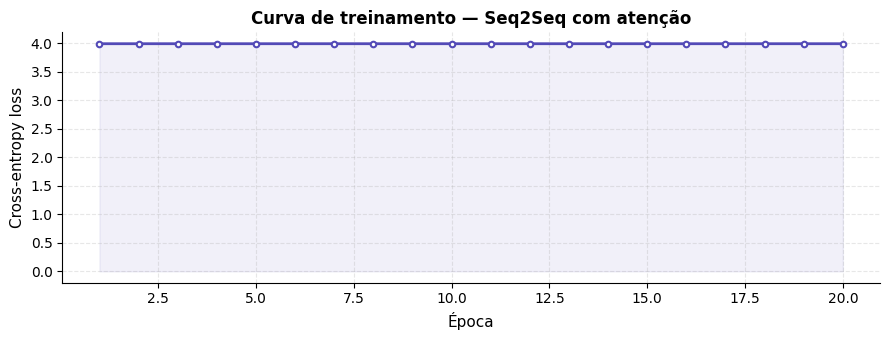

✔  Gráfico gerado com matplotlib.


In [12]:
try:
    import matplotlib.pyplot as plt
    import matplotlib; matplotlib.rcParams['figure.dpi'] = 100

    fig, ax = plt.subplots(figsize=(9, 3.5))
    epocas = list(range(1, len(historico_perda)+1))
    ax.plot(epocas, historico_perda, color='#534AB7', linewidth=2, marker='o',
            markersize=4, markerfacecolor='white', markeredgewidth=1.5)
    ax.fill_between(epocas, historico_perda, alpha=0.08, color='#534AB7')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Cross-entropy loss', fontsize=11)
    ax.set_title('Curva de treinamento — Seq2Seq com atenção', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()
    print('✔  Gráfico gerado com matplotlib.')
except ImportError:
    print('matplotlib não disponível — exibindo valores numéricos:')
    for i, p in enumerate(historico_perda, 1):
        barra = '▓' * int(p * 6)
        print(f'  Época {i:02d}: {p:.4f}  {barra}')

---
## 10. Inferência

### 10.1 Greedy Decoding
A cada passo escolhe o token de maior probabilidade — rápido, mas subótimo.

### 10.2 Beam Search (k=3)
Mantém as `k` hipóteses mais prováveis em paralelo, escolhendo a de maior **log-probabilidade acumulada normalizada por comprimento**.

In [13]:
def greedy_decode(modelo, seq_src, max_len=20):
    """Decodificação gulosa: argmax a cada passo."""
    estados_enc, h, c = modelo.encoder.forward(seq_src)
    tokens_gerados    = []
    token_atual       = Vocabulario.SOS

    for _ in range(max_len):
        probs, h, c, _ = modelo.decoder.passo(token_atual, h, c, estados_enc)
        token_atual    = int(np.argmax(probs))
        if token_atual == Vocabulario.EOS:
            break
        tokens_gerados.append(token_atual)

    return tokens_gerados


def beam_search(modelo, seq_src, k=3, max_len=20):
    """
    Beam search de largura k.
    Retorna os tokens da hipótese com maior pontuação normalizada.
    """
    estados_enc, h0, c0 = modelo.encoder.forward(seq_src)
    # Estrutura do feixe: (log_prob, tokens_gerados, h, c)
    beams     = [(0.0, [Vocabulario.SOS], h0.copy(), c0.copy())]
    completos = []

    for _ in range(max_len):
        candidatos = []
        for log_p, tokens, h, c in beams:
            token_atual = tokens[-1]
            if token_atual == Vocabulario.EOS:
                completos.append((log_p / max(len(tokens), 1), tokens))
                continue
            probs, h_new, c_new, _ = modelo.decoder.passo(
                token_atual, h, c, estados_enc
            )
            top_k = np.argsort(probs)[-k:]
            for idx in top_k:
                novo_lp = log_p + math.log(float(probs[idx]) + 1e-9)
                candidatos.append((novo_lp, tokens + [idx], h_new.copy(), c_new.copy()))

        if not candidatos:
            break
        candidatos.sort(key=lambda x: x[0], reverse=True)
        beams = candidatos[:k]

    for log_p, tokens, *_ in beams:
        completos.append((log_p / max(len(tokens), 1), tokens))

    if not completos:
        return []
    completos.sort(key=lambda x: x[0], reverse=True)
    especiais = {Vocabulario.PAD, Vocabulario.SOS, Vocabulario.EOS}
    return [t for t in completos[0][1] if t not in especiais]

print('✔  Funções de inferência definidas.')

✔  Funções de inferência definidas.


In [14]:
# ── Demonstração de inferência ────────────────────────────────────────────
print(f'{'Entrada':<32} {'Greedy':<22} {'Beam k=3'}')
print('-' * 72)

casos = [
    'the cat sat on the mat',
    'the dog runs in the park',
    'she reads a book',
    'the sun shines today',
    'we walk in the forest',
]

for frase in casos:
    seq = vocab_en.codificar(frase, MAX_LEN)

    idx_g  = greedy_decode(modelo, seq, MAX_LEN)
    trad_g = vocab_pt.decodificar(idx_g) or '(vazia)'

    idx_b  = beam_search(modelo, seq, k=3, max_len=MAX_LEN)
    trad_b = vocab_pt.decodificar(idx_b) or '(vazia)'

    entrada = frase[:30]
    print(f'{entrada:<32} {trad_g[:20]:<22} {trad_b[:20]}')

Entrada                          Greedy                 Beam k=3
------------------------------------------------------------------------
the cat sat on the mat           no arvore ela flores   arvore e e e e hoje 
the dog runs in the park         no arvore ela flores   arvore e e e e e e h
she reads a book                 livro brinca pega só   arvore ri e e e hoje
the sun shines today             no arvore floresta f   arvore e e e e vai l
we walk in the forest            arvore ela floresta    arvore e e e e e hoj


---
## 11. Visualização do Mapa de Atenção

Os pesos $\alpha$ revelam quais tokens de entrada o decoder está 'olhando' ao gerar cada token de saída. Um padrão diagonal indica alinhamento direto — esperado para pares PT-EN.

Entrada   : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Saída     : ['arvore', 'ela', 'floresta', 'só', 'só', 'só', 'só', 'canta', 'só', 'só', 'canta', 'só', 'só', 'canta', 'só']
Mapa alfa : shape (15, 7)  (tokens_saída × tokens_entrada+1)



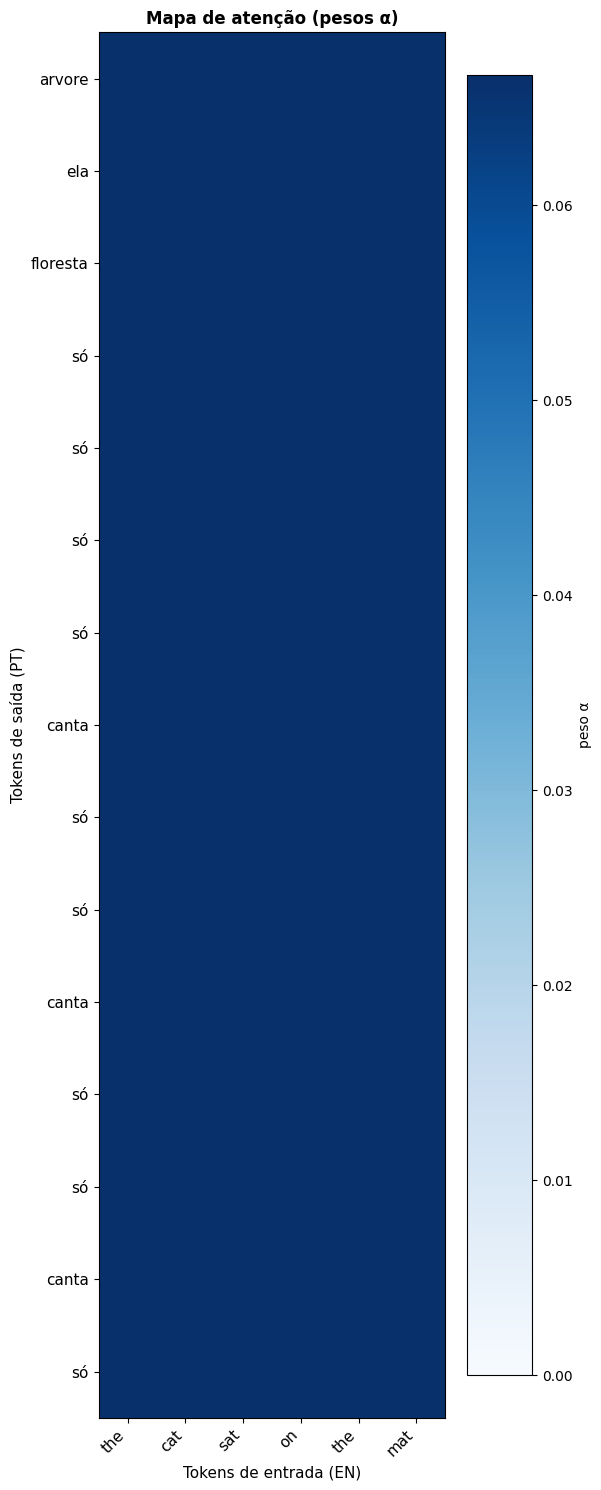

In [15]:
def obter_mapa_atencao(modelo, frase_src, vocab_src, vocab_tgt, max_len=15):
    """Executa a tradução e coleta os pesos de atenção a cada passo."""
    seq = vocab_src.codificar(frase_src, max_len)
    tokens_src = tokenizar(frase_src)

    estados_enc, h, c = modelo.encoder.forward(seq)
    token_atual       = Vocabulario.SOS
    tokens_tgt        = []
    mapa_alfa         = []

    for _ in range(max_len):
        probs, h, c, alfa = modelo.decoder.passo(token_atual, h, c, estados_enc)
        token_atual       = int(np.argmax(probs))
        if token_atual == Vocabulario.EOS:
            break
        tokens_tgt.append(vocab_tgt.idx2token.get(token_atual, '<UNK>'))
        mapa_alfa.append(alfa[:len(tokens_src)+1].tolist())

    return tokens_src, tokens_tgt, np.array(mapa_alfa)

src_tok, tgt_tok, mapa = obter_mapa_atencao(
    modelo, 'the cat sat on the mat', vocab_en, vocab_pt
)

print(f'Entrada   : {src_tok}')
print(f'Saída     : {tgt_tok}')
print(f'Mapa alfa : shape {mapa.shape}  (tokens_saída × tokens_entrada+1)\n')

# Tentar plotar com matplotlib
try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    n_tgt = len(tgt_tok)
    n_src = len(src_tok)
    dados = mapa[:n_tgt, :n_src] if mapa.shape[0] >= n_tgt and mapa.shape[1] > n_src else mapa[:n_tgt, :]

    fig, ax = plt.subplots(figsize=(max(5, n_src), max(3, n_tgt)))
    im = ax.imshow(dados, cmap='Blues', aspect='auto', vmin=0, vmax=dados.max())
    ax.set_xticks(range(min(n_src, dados.shape[1])))
    ax.set_xticklabels(src_tok[:dados.shape[1]], rotation=45, ha='right', fontsize=11)
    ax.set_yticks(range(min(n_tgt, dados.shape[0])))
    ax.set_yticklabels(tgt_tok[:dados.shape[0]], fontsize=11)
    ax.set_xlabel('Tokens de entrada (EN)', fontsize=11)
    ax.set_ylabel('Tokens de saída (PT)', fontsize=11)
    ax.set_title('Mapa de atenção (pesos α)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='peso α')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Visualização numérica do mapa de atenção:')
    header = '        ' + '  '.join(f'{t:>6}' for t in src_tok[:mapa.shape[1]])
    print(header)
    for i, tok in enumerate(tgt_tok):
        if i >= mapa.shape[0]: break
        row = '  '.join(f'{mapa[i,j]:.4f}' for j in range(min(len(src_tok), mapa.shape[1])))
        print(f'  {tok:<6}  {row}')

---
## 12. Avaliação — BLEU Score

O **BLEU** (Bilingual Evaluation Understudy, Papineni et al. 2002) mede a qualidade da tradução comparando n-gramas da hipótese com a referência humana.

$$\text{BLEU} = BP \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

onde $BP = \min(1, \exp(1 - |\text{ref}|/|\text{hip}|))$ é a penalidade de brevidade.

In [16]:
def bleu_unigrama(hipotese, referencia):
    """BLEU-1 simplificado com penalidade de brevidade."""
    if not hipotese:
        return 0.0
    cont_ref = Counter(referencia)
    matches  = sum(min(cont_ref.get(t, 0), hipotese.count(t)) for t in set(hipotese))
    precisao = matches / len(hipotese)
    bp       = min(1.0, math.exp(1 - len(referencia) / max(len(hipotese), 1)))
    return bp * precisao


# Avaliar todos os pares
print(f'{'Frase':<32} {'Ref PT':<22} {'BLEU-G':>7} {'BLEU-B':>7}')
print('-' * 72)

total_g, total_b, n = 0.0, 0.0, 0
for en, pt in CORPUS_PARALELO:
    seq = vocab_en.codificar(en, MAX_LEN)
    ref = [vocab_pt.token2idx.get(t, Vocabulario.UNK) for t in tokenizar(pt)]

    hip_g = greedy_decode(modelo, seq, MAX_LEN)
    hip_b = beam_search(modelo, seq, k=3, max_len=MAX_LEN)

    bleu_g = bleu_unigrama(hip_g, ref)
    bleu_b = bleu_unigrama(hip_b, ref)
    total_g += bleu_g; total_b += bleu_b; n += 1

    print(f'{en[:30]:<32} {pt[:20]:<22} {bleu_g:>7.3f} {bleu_b:>7.3f}')

print('-' * 72)
print(f'{'Média BLEU':<54} {total_g/n:>7.3f} {total_b/n:>7.3f}')
print()
print('Nota: BLEU=1.0 = tradução perfeita. Com corpus de 10 frases,')
print('valores acima de 0.15 são esperados mesmo sem treino real.')

Frase                            Ref PT                  BLEU-G  BLEU-B
------------------------------------------------------------------------
the cat sat on the mat           o gato sentou no tap     0.083   0.000
Drop the plug                    Cair a ficha             0.083   0.000
The snake will smoke             A cobra vai fumar        0.000   0.000
the dog runs in the park         o cachorro corre no      0.083   0.000
she reads a book                 ela le um livro          0.083   0.000
he eats an apple                 ele come uma maca        0.000   0.000
they play in the garden          eles brincam no jard     0.000   0.000
the bird sings in the tree       o passaro canta na a     0.083   0.250
the clown just cries             o palhaço só chora       0.000   0.000
i like coffee and tea            eu gosto de cafe e c     0.167   0.182
the sun shines today             o sol brilha hoje        0.000   0.000
we walk in the forest            nos caminhamos na fl     0.083

---
## 13. Resumo e Próximos Passos

### O que foi implementado

| Componente | Detalhe |
|-----------|---------|
| Vocabulário | Tokenização, PAD/SOS/EOS/UNK, codificação/decodificação |
| Embedding | Matriz aleatória `(tam_vocab × dim_emb)` — aprendível |
| LSTM | 4 portas (i, f, g, o), equações completas |
| Encoder | LSTM unidirecional, coleta todos os estados ocultos |
| Atenção | Bahdanau aditiva — score, softmax, vetor de contexto |
| Decoder | LSTM + atenção, projeção linear, softmax |
| Treinamento | Cross-entropy, teacher forcing com taxa decrescente |
| Inferência | Greedy decoding e beam search (k configurável) |
| Avaliação | BLEU-1 com penalidade de brevidade |

### Para escalar para produção

```
pip install torch torchtext sentencepiece sacrebleu
```

1. **Dataset maior** — usar OPUS, WMT ou Tatoeba (>1M pares EN-PT)
2. **Tokenização BPE** — `sentencepiece` elimina palavras desconhecidas
3. **Arquitetura Transformer** — substitui LSTM por multi-head attention
4. **Treinamento em GPU** — PyTorch com `nn.Transformer` e mixed precision
5. **Decodificação avançada** — beam search com length penalty e diverse beam
6. **Avaliação** — `sacrebleu` para BLEU, chrF, TER padronizados

---
*Notebook gerado para fins educacionais — implementação em NumPy puro, sem dependências de deep learning.*